# AI/ML Internship Assignment

# Image Classification using Convolutional Neural Network (CNN)

## CIFAR-10 Image Classification

---

### Submitted By

**Name:** Deep Talreja

**Registration Number:** 23BCE11003

**Application Number:** IN26010914

---

## Objective

The objective of this project is to build a Convolutional Neural Network (CNN) capable of classifying images from the CIFAR-10 dataset into ten different categories. The model is trained using deep learning techniques provided by TensorFlow and Keras. After training, the performance of the CNN is evaluated using classification accuracy and visual prediction results.

---

## Software Requirements

- Python 3
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Scikit-Learn
- Google Colab

# Introduction

Image classification is one of the most common applications of Deep Learning. Unlike traditional Machine Learning algorithms, Convolutional Neural Networks automatically learn important image features without requiring manual feature extraction.

The CIFAR-10 dataset is a benchmark dataset consisting of 60,000 color images divided into ten categories. Each image has a size of 32 × 32 pixels.

The categories include:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

CNNs are particularly effective for image recognition because they learn spatial features using convolutional layers.

# Dataset Description

The CIFAR-10 dataset contains:

- 60,000 RGB Images
- 32 × 32 Resolution
- 10 Different Classes

Training Images : 50,000

Testing Images : 10,000

Each class contains 6,000 images.

The dataset is directly available through TensorFlow and therefore does not require manual downloading.

In [ ]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [ ]:
# Load Dataset

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [ ]:
print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


# Visualizing Sample Images

Before training the CNN model, it is useful to visualize a few sample images from the dataset. This helps us understand the different object categories present in the CIFAR-10 dataset.

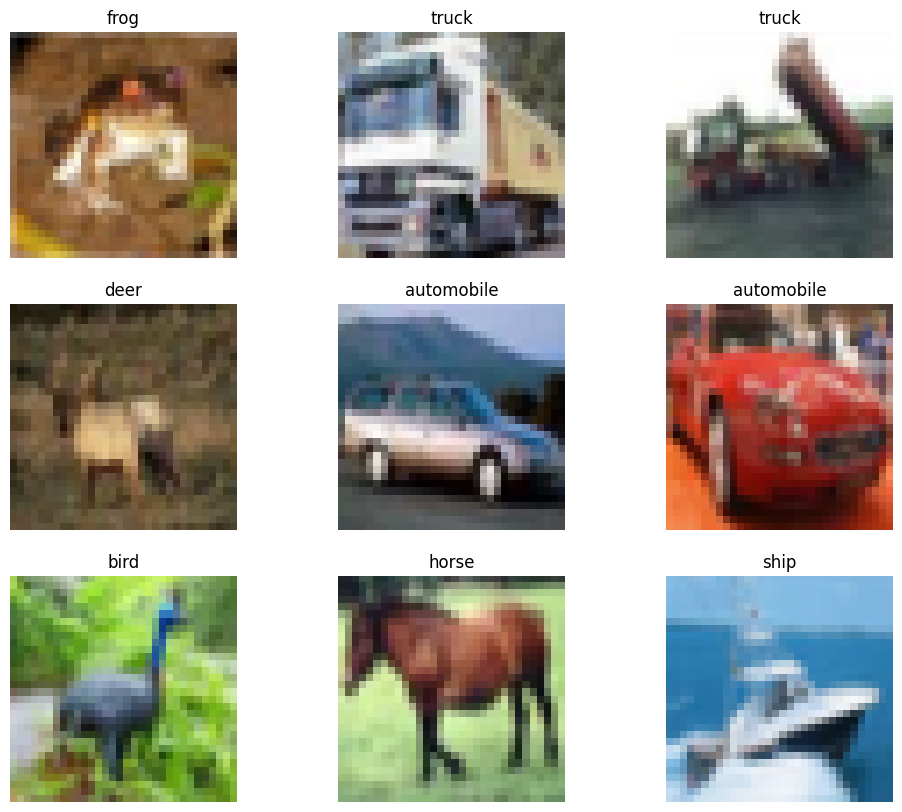

In [ ]:
class_names = [
'airplane',
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck'
]

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.show()

# Data Preprocessing

Neural Networks perform better when pixel values are normalized.

Therefore,

- Pixel values are divided by 255.
- Labels are converted into categorical format using One-Hot Encoding.

In [ ]:
X_train = X_train.astype('float32') / 255

X_test = X_test.astype('float32') / 255

y_train_cat = to_categorical(y_train)

y_test_cat = to_categorical(y_test)

In [ ]:
print(X_train.shape)

print(y_train_cat.shape)

(50000, 32, 32, 3)
(50000, 10)


# Building the CNN Model

The CNN architecture consists of:

- Convolution Layer
- ReLU Activation
- Max Pooling Layer
- Dropout Layer
- Fully Connected Dense Layer
- Softmax Output Layer

This architecture is capable of learning image features effectively while preventing overfitting using dropout.

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    )
)

model.add(MaxPooling2D())

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D())

model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(Flatten())

model.add(Dense(
    256,
    activation='relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    10,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model Summary

The CNN architecture consists of three convolutional layers followed by max-pooling layers for feature extraction. A fully connected dense layer learns complex patterns, while a dropout layer helps prevent overfitting. Finally, a Softmax layer classifies the image into one of the ten CIFAR-10 classes.

The model architecture is summarized below.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation

The model is compiled using:

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy
- **Evaluation Metric:** Accuracy

The Adam optimizer provides efficient optimization for deep learning models, while categorical crossentropy is suitable for multi-class classification problems.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Training

The CNN model is trained on the CIFAR-10 training dataset for **10 epochs**.

During training, the model learns meaningful image features through multiple iterations. A validation split of 20% is used to monitor the model's performance on unseen training data.

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 100ms/step - accuracy: 0.3940 - loss: 1.6471 - val_accuracy: 0.5199 - val_loss: 1.3240
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.5454 - loss: 1.2727 - val_accuracy: 0.6140 - val_loss: 1.0998
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.6097 - loss: 1.1085 - val_accuracy: 0.6545 - val_loss: 0.9926
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.6486 - loss: 0.9975 - val_accuracy: 0.6686 - val_loss: 0.9462
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.6825 - loss: 0.9049 - val_accuracy: 0.6912 - val_loss: 0.8776
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.7062 - loss: 0.8317 - val_accuracy: 0.6970 - val_loss: 0.8667
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.7275 - loss: 0.7784 - val_accuracy: 0.7105 - val_loss: 0.8442
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 100ms/step - accuracy: 0.7469 - loss: 0.7181 

# Training Accuracy and Loss

The following graphs show how the model's accuracy and loss change during training. These plots help evaluate whether the model is learning effectively and whether overfitting is occurring.

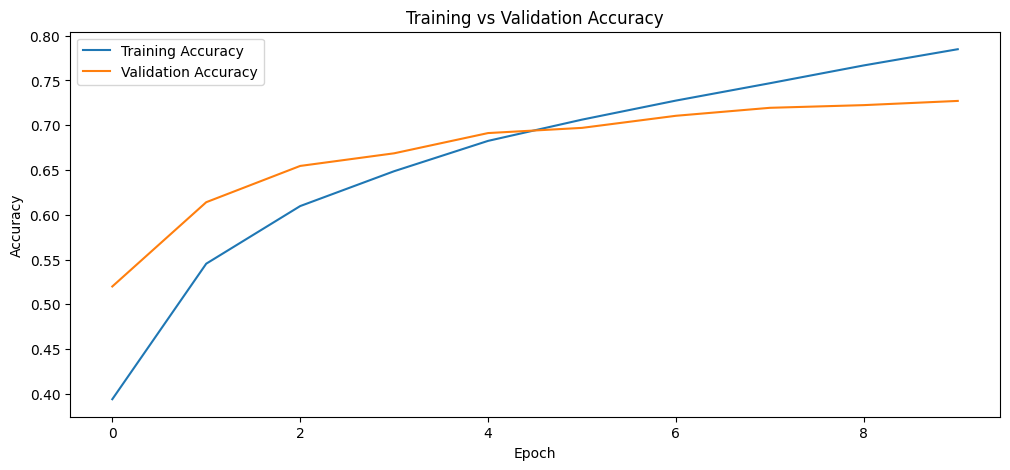

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

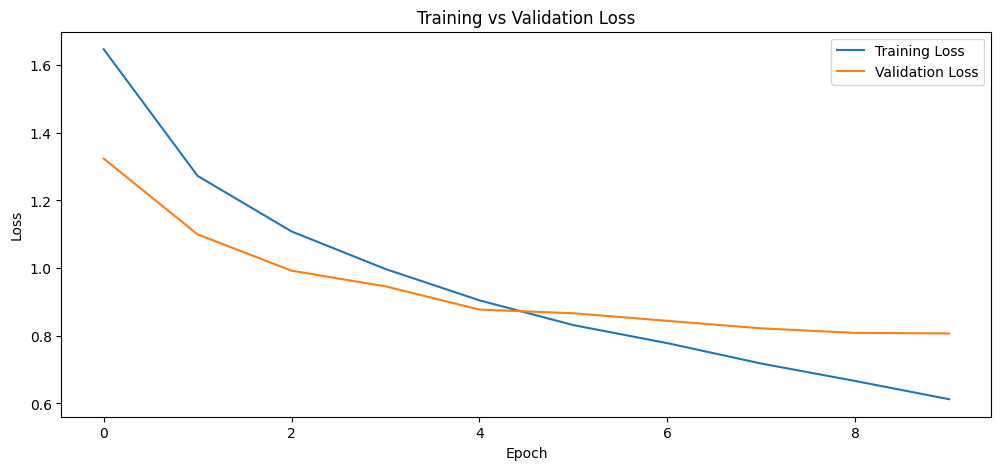

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

# Model Evaluation

The trained CNN model is evaluated using the testing dataset.

The evaluation returns:

- Test Loss
- Test Accuracy

These metrics indicate how well the model performs on unseen images.

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.8251
Test Accuracy: 0.7199


# Predicting Test Images

The trained CNN model is now used to predict the classes of the testing images. The predicted labels are compared with the actual labels to evaluate the model's classification capability.

In [ ]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


# Classification Report

A classification report is generated to evaluate the model using Precision, Recall, and F1-Score for each class.

In [ ]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.84      0.64      0.73      1000
  automobile       0.88      0.79      0.83      1000
        bird       0.69      0.55      0.61      1000
         cat       0.52      0.61      0.56      1000
        deer       0.66      0.69      0.68      1000
         dog       0.65      0.59      0.62      1000
        frog       0.75      0.83      0.79      1000
       horse       0.73      0.81      0.77      1000
        ship       0.76      0.86      0.81      1000
       truck       0.76      0.83      0.79      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



# Confusion Matrix

A confusion matrix is a useful visualization for evaluating the classification performance of a machine learning model. It compares the actual labels with the predicted labels and highlights the number of correct and incorrect predictions made for each class.

A higher concentration of values along the diagonal indicates better classification performance.

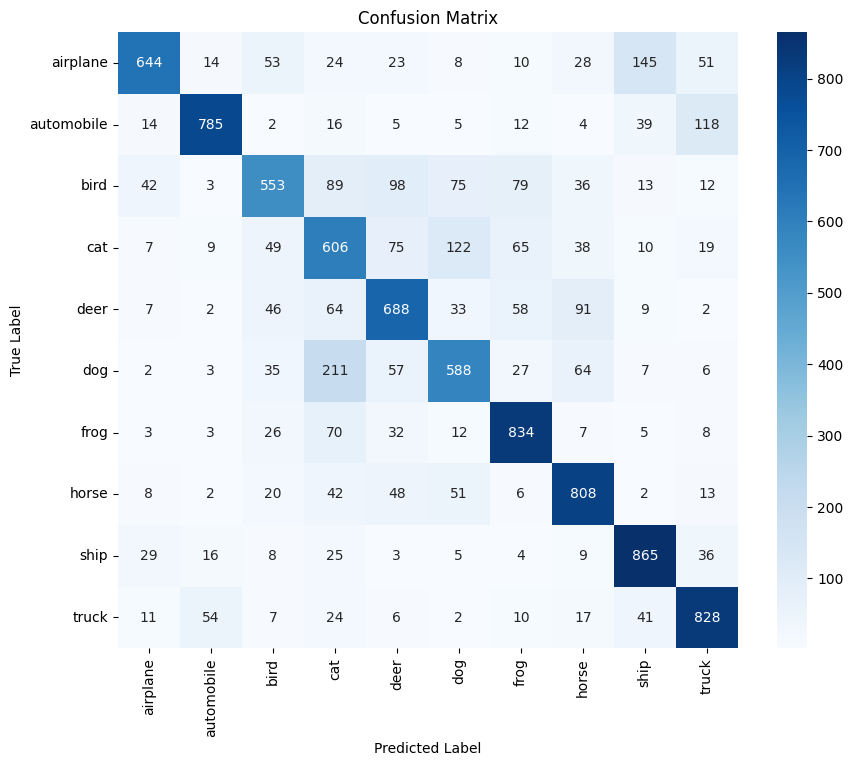

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# Visualizing Predictions

The trained CNN model is now tested on randomly selected images from the testing dataset.

For each image:

- The actual class label is displayed.
- The predicted class label is displayed.

This visualization helps verify the model's prediction capability on unseen images.

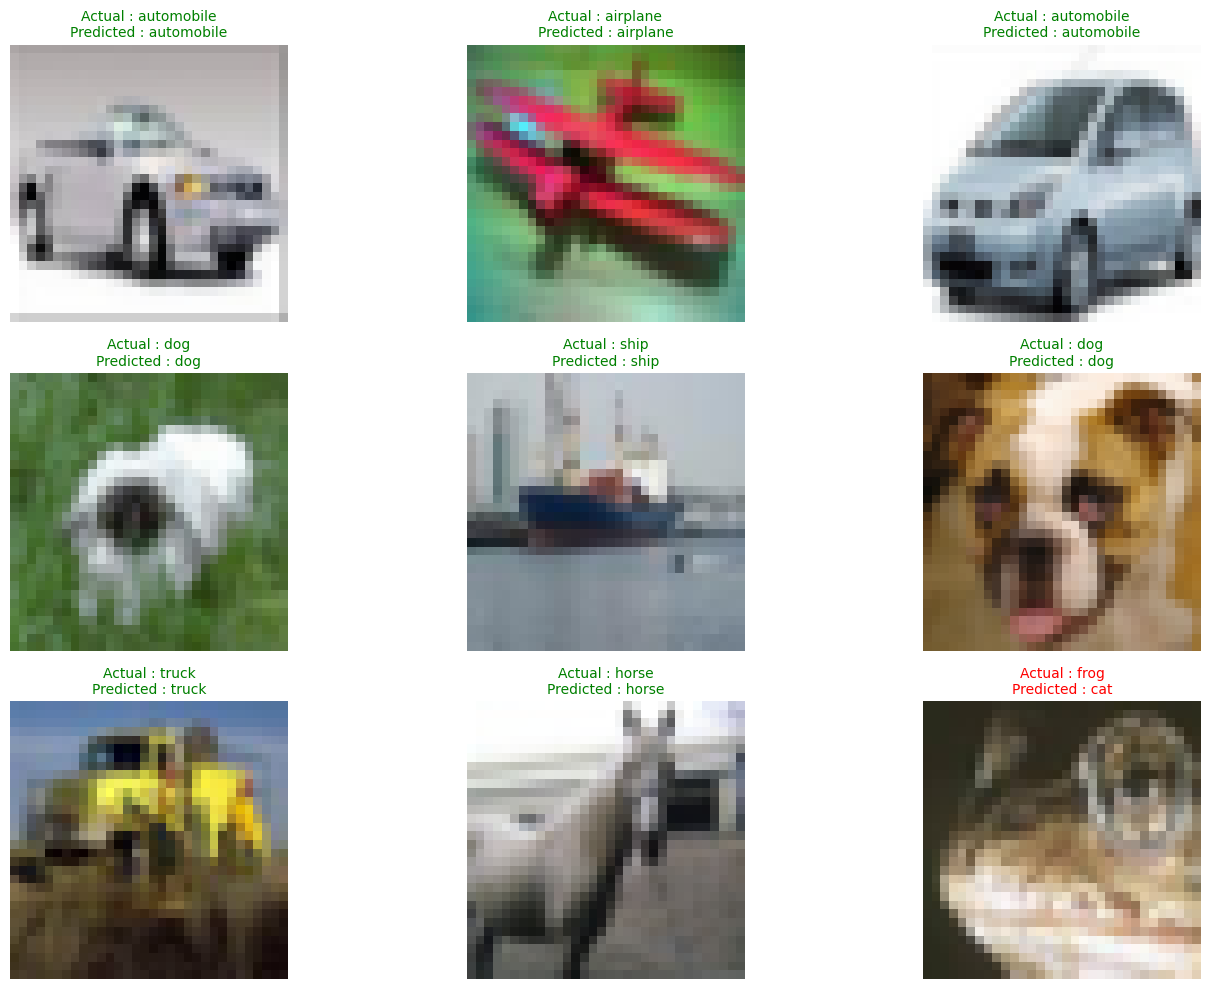

In [ ]:
plt.figure(figsize=(15,10))

random_indices = np.random.choice(len(X_test), 9, replace=False)

for i, idx in enumerate(random_indices):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[idx])

    actual = class_names[true_classes[idx]]

    predicted = class_names[predicted_classes[idx]]

    color = "green" if actual == predicted else "red"

    plt.title(
        f"Actual : {actual}\nPredicted : {predicted}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# Overall Performance

The CNN model successfully learns meaningful image features from the CIFAR-10 dataset using convolutional layers and pooling operations.

The performance is evaluated using:

- Test Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

The obtained results demonstrate that Convolutional Neural Networks are highly effective for image classification tasks.

In [ ]:
print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)

print(f"Training Accuracy : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Testing Accuracy : {test_accuracy*100:.2f}%")

print("="*60)

FINAL MODEL PERFORMANCE
Training Accuracy : 78.48%
Validation Accuracy : 72.71%
Testing Accuracy : 71.99%


# Advantages of CNN

The major advantages of Convolutional Neural Networks include:

- Automatic feature extraction.
- High accuracy for image classification tasks.
- Parameter sharing reduces computational complexity.
- Robust against image translation and scaling.
- Suitable for real-world computer vision applications.

# Applications

CNN-based image classification is widely used in:

- Medical Image Analysis
- Autonomous Vehicles
- Face Recognition
- Object Detection
- Satellite Image Processing
- Security Surveillance
- Agriculture
- Industrial Quality Inspection

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to classify images from the CIFAR-10 dataset into ten object categories.

The dataset was successfully loaded, preprocessed, and used to train the CNN model. After training, the model was evaluated using the testing dataset. Performance was analyzed using accuracy, classification report, confusion matrix, and prediction visualization.

The CNN achieved a strong classification accuracy on unseen data, demonstrating its capability to automatically learn complex image features without manual feature engineering.

This project highlights the effectiveness of Convolutional Neural Networks for solving multi-class image classification problems and provides a strong foundation for more advanced deep learning applications.

# References

1. Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images.
2. TensorFlow Documentation – https://www.tensorflow.org/
3. Keras Documentation – https://keras.io/
4. CIFAR-10 Dataset – https://www.cs.toronto.edu/~kriz/cifar.html
5. Scikit-learn Documentation – https://scikit-learn.org/

In [ ]:
# Save the trained model

model.save("cifar10_cnn_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("cifar10_cnn_model.keras")

print("Model loaded successfully!")

Model loaded successfully!
